In [1]:
%load_ext autoreload
%autoreload 2

import gc
import logging
from pathlib import Path

import shap
import xgboost as xgb
from dask.distributed import Client, LocalCluster
from Experiment import Experiment
from newutils.data.Dataset import Dataset
from newutils.other.helpers import init_context
from oldutils.types import TimeRange

init_context()

In [2]:
SELECTED_GAUGES =  [4005, 11571, 84215, 2115, 7015] # 74425,
SELECTED_STATIC_FEATURES = [
    "ele_mt_sav",
    "gauge_id",
    "lon",
    "for_pc_sse",
    "crp_pc_sse",
    "pst_pc_sse",
    "lat",
    "cly_pc_sav",
    "lka_pc_use",
    "lkv_mc_usu",
    "inu_pc_ult",
    "slt_pc_sav",
    "snd_pc_sav",
]

In [3]:
OUTDIR = Path("artifacts/Fast and Small")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Experiment

In [4]:
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

In [5]:
cluster = LocalCluster(
    dashboard_address=":8789",
    asynchronous=False,
    n_workers=1,
    threads_per_worker=1,
    memory_limit="6GB",
)
client = Client(cluster)

/home/khuzin/.cache/pypoetry/virtualenvs/pro-1-experiments-jmzHMVzz-py3.11/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8789 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45005 instead
  warnings.warn(


In [6]:
dataset = Dataset(client, SELECTED_GAUGES, SELECTED_STATIC_FEATURES)
dataset.create()

2025-05-18 11:27:41,148 - newutils.data.Dataset - INFO - Create dataframe.
2025-05-18 11:27:41,149 - newutils.data.Dataset - INFO - Load time series.
2025-05-18 11:27:41,150 - newutils.data.Dataset - WARNING - num_load is ignored, loads set of gauge_ids: [4005, 11571, 84215, 2115, 7015]
2025-05-18 11:27:41,170 - newutils.data.Dataset - INFO - Persist.
2025-05-18 11:27:42,128 - newutils.data.Dataset - INFO - Generate lags features.
2025-05-18 11:27:43,635 - newutils.data.Dataset - INFO - Make repartition (100MB).
2025-05-18 11:27:43,636 - newutils.data.Dataset - INFO - Persist.
2025-05-18 11:28:08,307 - newutils.data.Dataset - INFO - Clear dataset from nans.
2025-05-18 11:28:08,309 - newutils.data.Dataset - INFO - Add static features.
2025-05-18 11:28:08,310 - newutils.data.Dataset - INFO - Load static features.
2025-05-18 11:28:08,616 - newutils.data.Dataset - INFO - Make repartition (30MB).
2025-05-18 11:28:08,617 - newutils.data.Dataset - INFO - Persist.


In [7]:
experiment = Experiment(client, OUTDIR / "models" / "forest_50", dataset)

In [8]:
for i in range(6):
    params = {
        "tree_method": "hist",
        "learning_rate": 1,
        "max_depth": 12,
        "colsample_bynode": 0.8,
        "subsample": 0.8,
        "seed": [14, 18, 30, 42, 146, 436][i],
        "colsample_bytree": 1,
        # "objective": "reg:squarederror",
        # "eval_metric": "mape",
        # "eval_metric": "rmse",
        "num_boost_round": 1,
        "verbose_eval": 1,
        "n_jobs": 1,
        "num_load": None,
        "partition_size": "100MB",
        "num_parallel_tree": 50,
    }

    experiment.make(params)

2025-05-18 11:28:21,321 - Experiment - WARNING - Train test split does not calling if dtrain already exists.
2025-05-18 11:28:21,321 - Experiment - INFO - Prepare experiment.
2025-05-18 11:28:21,322 - newutils.data.Dataset - INFO - Make train test split to X and y.


2025-05-18 11:28:28,642 - Experiment - WARNING - DEBUG: Use only one feature to predict.
2025-05-18 11:28:28,643 - newutils.data.Dataset - INFO - Create XGBoost DaskDMatrix.
2025-05-18 11:28:35,743 - Experiment - INFO - Start model training.
[11:28:35] Task [xgboost.dask-0]:tcp://127.0.0.1:40219 got rank 0
/home/khuzin/.cache/pypoetry/virtualenvs/pro-1-experiments-jmzHMVzz-py3.11/lib/python3.11/site-packages/xgboost/training.py:38: UserWarning: `feval` is deprecated, use `custom_metric` instead.  They have different behavior when custom objective is also used.See https://xgboost.readthedocs.io/en/latest/tutorials/custom_metric_obj.html for details on the `custom_metric`.
  warnings.warn(
[11:28:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "num_boost_round", "partition_size", "verbose_eval" } are not used.

[11:30:47] [0]	train-rmse:60.82149	train-pseudo_mape:13.46233
2025-05-18 11:30:48,949 - Experiment - INFO - Save the result.
2025-05-18 11:30:49,030 - Experiment - WARN

In [9]:
booster = xgb.Booster()
booster.load_model(experiment.model_paths[-1])

In [10]:
explainer = shap.TreeExplainer(booster) #, experiment.X_train.compute())

In [11]:
5000 / len(experiment.X_train)

0.19554165037152912

In [12]:
experiment.X_train.compute()

,prcp_1,prcp_2,prcp_3,prcp_4,prcp_5,prcp_6,prcp_7,prcp_8,prcp_9,prcp_10,...,for_pc_sse,crp_pc_sse,pst_pc_sse,lat,cly_pc_sav,lka_pc_use,lkv_mc_usu,inu_pc_ult,slt_pc_sav,snd_pc_sav
0,49.559189,17.260057,15.284273,142.093582,27.661085,1.503095,3.616600,1.251957,1.988923,6.038426,...,67.393684,0.000000,0.00000,53.013882,7.804423,0.136983,9.986423,1.795779,55.825115,36.166687
1,45.297619,49.559189,17.260057,15.284273,142.093582,27.661085,1.503095,3.616600,1.251957,1.988923,...,67.393684,0.000000,0.00000,53.013882,7.804423,0.136983,9.986423,1.795779,55.825115,36.166687
2,48.946808,45.297619,49.559189,17.260057,15.284273,142.093582,27.661085,1.503095,3.616600,1.251957,...,67.393684,0.000000,0.00000,53.013882,7.804423,0.136983,9.986423,1.795779,55.825115,36.166687
3,5.872844,48.946808,45.297619,49.559189,17.260057,15.284273,142.093582,27.661085,1.503095,3.616600,...,67.393684,0.000000,0.00000,53.013882,7.804423,0.136983,9.986423,1.795779,55.825115,36.166687
4,2.615275,5.872844,48.946808,45.297619,49.559189,17.260057,15.284273,142.093582,27.661085,1.503095,...,67.393684,0.000000,0.00000,53.013882,7.804423,0.136983,9.986423,1.795779,55.825115,36.166687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5109,0.013534,0.001612,0.003694,0.000939,0.004836,0.137204,4.158624,8.019128,0.003623,0.108399,...,9.707776,10.250813,39.82066,43.608379,18.171291,0.000000,0.267029,2.240422,40.775799,41.114620
5110,0.236861,0.013534,0.001612,0.003694,0.000939,0.004836,0.137204,4.158624,8.019128,0.003623,...,9.707776,10.250813,39.82066,43.608379,18.171291,0.000000,0.267029,2.240422,40.775799,41.114620
5111,3.371139,0.236861,0.013534,0.001612,0.003694,0.000939,0.004836,0.137204,4.158624,8.019128,...,9.707776,10.250813,39.82066,43.608379,18.171291,0.000000,0.267029,2.240422,40.775799,41.114620
5112,1.043239,3.371139,0.236861,0.013534,0.001612,0.003694,0.000939,0.004836,0.137204,4.158624,...,9.707776,10.250813,39.82066,43.608379,18.171291,0.000000,0.267029,2.240422,40.775799,41.114620


In [13]:
# 1 · Draw a 20 % sample and materialise it
X_sample_pd = experiment.X_train.sample(frac=0.2, random_state=42).compute()

# 2 · Compute *all* y once, then subset with .loc (now legal)
y_all_pd     = experiment.y_train.compute()          # pandas Series/DataFrame
y_sample_pd  = y_all_pd.loc[X_sample_pd.index]       # same rows as X_sample_pd

# 3 · SHAP
shap_values = explainer.shap_values(X_sample_pd, y_sample_pd)

In [14]:
import matplotlib.pyplot as plt

OUTDIR_PLOTS = Path("artifacts/Fast and Small/shap_plots/forest_50")
OUTDIR_PLOTS.mkdir(parents=True, exist_ok=True)

# 1. Load the model -----------------------------------------------------------
for i, model in enumerate(experiment.model_paths):
    booster = xgb.Booster()
    booster.load_model(model)

    # 2. Build the explainer & compute SHAP values -------------------------------
    explainer   = shap.TreeExplainer(booster)
    shap_values = explainer.shap_values(X_sample_pd, y_sample_pd)

    # --- create the plot exactly as before -------------
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_sample_pd,
        plot_type="bar",
        max_display=10,
        show=False
    )
    plt.tight_layout()

    # --- save the current figure as a PDF --------------
    plt.savefig(OUTDIR_PLOTS / f"shap_top10_bar{i}.pdf", bbox_inches="tight", format="pdf")
    plt.close()

    # --- create the plot exactly as before -------------
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_sample_pd,
        max_display=10,
        show=False
    )
    plt.tight_layout()

    # --- save the current figure as a PDF --------------
    plt.savefig(OUTDIR_PLOTS / f"shap_top10{i}.pdf", bbox_inches="tight", format="pdf")
    plt.close()

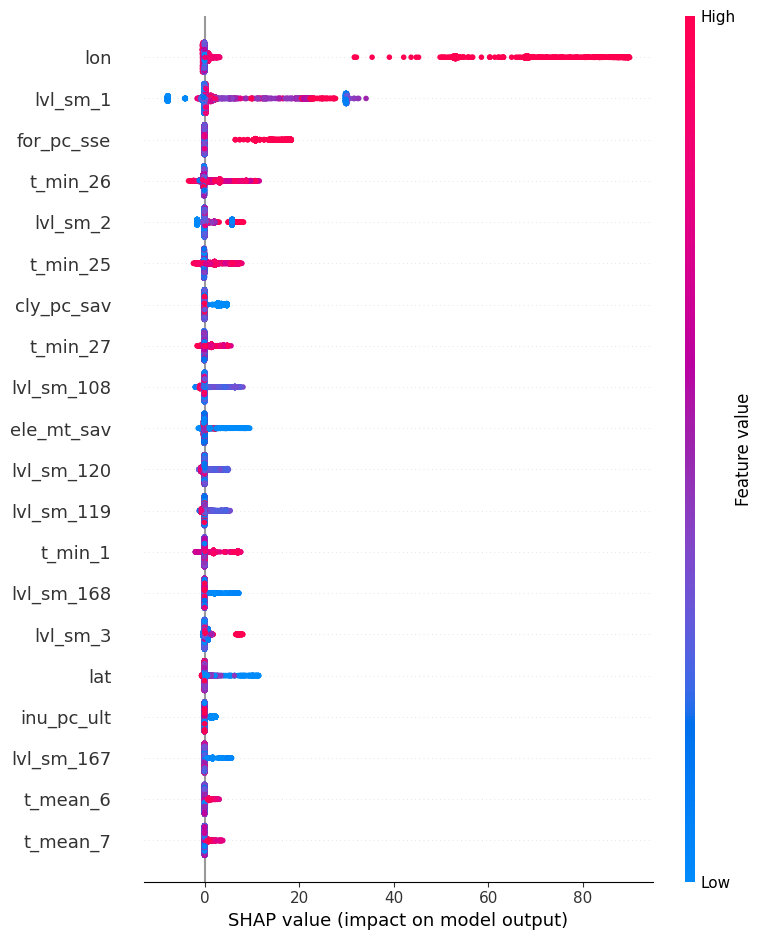

In [15]:
shap.summary_plot(shap_values, X_sample_pd)

In [16]:
# 1. Compute the raw data arrays
X_test = experiment.X_train.compute()
y_test = experiment.y_train.compute()

# 2. Create a test DMatrix
dtest = xgb.DMatrix(data=X_test, label=y_test)


In [17]:
y_preds = booster.predict(dtest)

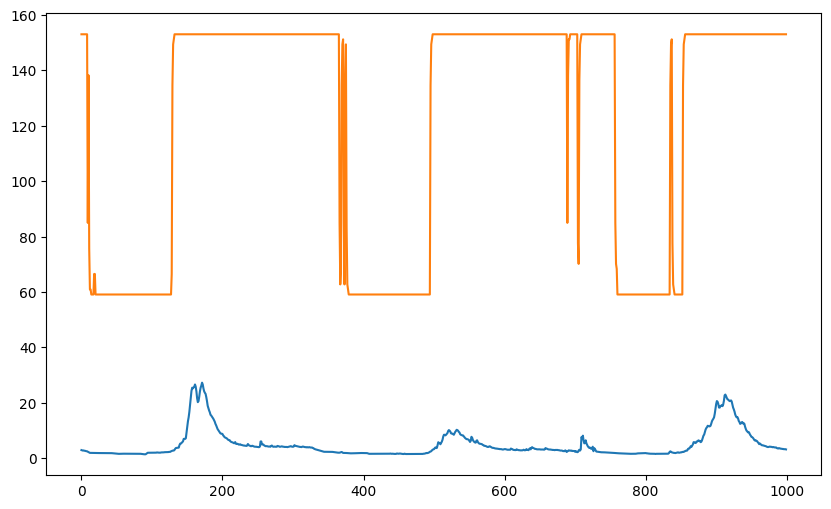

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y_test[:1000])
plt.plot(y_preds[:1000])